In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings("ignore")

In [88]:
#set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color   = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color    = viridis_colors[2]
danger_color    = '#800000'
netural_color   = viridis_colors[4]
custom_palette  = viridis_colors

## Exploratory Data Analysis

In [89]:
df = pd.read_csv('Supply_Chain_Dataset.csv', encoding='latin1')  # latin1 covers 256 chars; safe fallback for legacy CSVs
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [90]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Drop duplicate rows if any
original_shape = df.shape
df.drop_duplicates(inplace=True)
print(f"\nDropped {original_shape[0] - df.shape[0]} duplicate rows.")

# ✅ BUG FIX 1: Drop high-missing columns BEFORE dropna()
# 'Order Zipcode' has 155,679 missing and 'Product Description' has 180,519 missing.
# Calling dropna() before removing these columns wipes ALL rows → 0 rows left.
# Solution: drop these columns first, THEN dropna().
columns_to_drop_first = ['Order Zipcode', 'Product Description', 'Customer Lname', 'Customer Zipcode']
df.drop(columns=columns_to_drop_first, inplace=True, errors='ignore')
print("\n✅ High-missing columns dropped before dropna()")

# Re-check missing values after removing those columns
missing_after = df.isnull().sum()
print("\nMissing values per column after dropping high-missing columns:")
print(missing_after[missing_after > 0])

# Now safely drop rows with remaining missing values
if missing_after.any():
    print("\nDropping rows with missing values...")
    df.dropna(inplace=True)
    print("Missing values after dropna:")
    print(df.isnull().sum().sum())
else:
    print("No missing values remain.")

print("\nShape of the dataset:")
print(df.shape)
df.head()

Missing values per column:
Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market       

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [91]:
# Print the remaining column names and count
print("Column names:")
for column in df.columns:
    print(column)
print(f"\nTotal columns: {df.shape[1]}")

Column names:
Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Password
Customer Segment
Customer State
Customer Street
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Product Card Id
Product Category Id
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode

Total columns: 49


In [92]:
# ── DROP REMAINING UNNECESSARY COLUMNS ───────────────────────────────────
columns_to_drop = [
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Street',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # errors='ignore' skips already-dropped cols
print("✅ Columns dropped")

# ✅ BUG FIX 2: Actual value in dataset is 'Shipping canceled' (lowercase 'c'), NOT 'Shipping Canceled'
df = df[df['Delivery Status'] != 'Shipping canceled']
print("✅ Shipping canceled rows removed")

# ── CONVERT DATE COLUMNS TO DATETIME ─────────────────────────────────────
df['order date (DateOrders)']    = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])
print("✅ Date columns converted to datetime")

print("\n📊 SHAPE (rows, cols):")
print(df.shape)

print("\n📋 COLUMN NAMES LEFT:")
print(df.columns.tolist())

print("\n🔍 MISSING VALUES:")
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values found ✅")
else:
    print(missing)
    print(f"\nTotal missing cells: {df.isnull().sum().sum()}")
    print(f"Missing %:\n{(df.isnull().sum() / len(df) * 100).round(2)}")

df.head()

✅ Columns dropped
✅ Shipping canceled rows removed
✅ Date columns converted to datetime

📊 SHAPE (rows, cols):
(172765, 20)

📋 COLUMN NAMES LEFT:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode']

🔍 MISSING VALUES:
No missing values found ✅


,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [93]:
# Value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())


Value counts for 'Type':
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Value counts for 'Days for shipping (real)':
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Value counts for 'Days for shipment (scheduled)':
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Value counts for 'Delivery Status':
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Value counts for 'Late_delivery_risk':
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Value counts for 'Customer Country':
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Value counts for 'Customer Segment':
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Value co

In [94]:
# ── CALCULATING ORDER PROCESSING TIME AND DELAY ───────────────────────────

# Order Processing Time (days between order and shipping)
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

# ✅ BUG FIX 3: Use 'Days for shipment (scheduled)' — the scheduled delivery days column.
# 'Days for shipping (real)' is the actual days taken, not the scheduled target.
# Delay = how many extra days beyond what was scheduled
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

# Is Delayed flag
df['Is_Delayed'] = df['Delay'] > 0

# Extract date parts
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day']   = df['order date (DateOrders)'].dt.day
df['order_hour']  = df['order date (DateOrders)'].dt.hour

print("✅ New columns added:")
print(df[['order date (DateOrders)',
          'shipping date (DateOrders)',
          'Order Processing Time',
          'Delay',
          'Is_Delayed',
          'order_month',
          'order_day',
          'order_hour']].head())

print("\n📊 Summary Stats:")
df.describe()

✅ New columns added:
  order date (DateOrders) shipping date (DateOrders)  Order Processing Time  \
0     2018-01-31 22:56:00        2018-02-03 22:56:00                      3   
1     2018-01-13 12:27:00        2018-01-18 12:27:00                      5   
2     2018-01-13 12:06:00        2018-01-17 12:06:00                      4   
3     2018-01-13 11:45:00        2018-01-16 11:45:00                      3   
4     2018-01-13 11:24:00        2018-01-15 11:24:00                      2   

   Delay  Is_Delayed  order_month  order_day  order_hour  
0     -1       False            1         31          22  
1      1        True            1         13          12  
2      0       False            1         13          12  
3     -1       False            1         13          11  
4     -2       False            1         13          11  

📊 Summary Stats:


,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_day,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,15.739803,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,8.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,16.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,23.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,31.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,8.823467,6.927276


In [95]:
# Create a profitability category based on order profit
profitability = np.where(df['Order Profit Per Order'] > 0, 'Profit',
                np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Breakeven'))
df['Profitability Flag']    = profitability
df['Profit_Loss_Breakeven'] = df['Profitability Flag']

print("\nValue counts for 'Profit_Loss_Breakeven':")
print(df['Profit_Loss_Breakeven'].value_counts())


Value counts for 'Profit_Loss_Breakeven':
Profit_Loss_Breakeven
Profit       139354
Loss          32295
Breakeven      1116
Name: count, dtype: int64


In [96]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit       0.80661
Loss         0.18693
Breakeven    0.00646
Name: proportion, dtype: float64

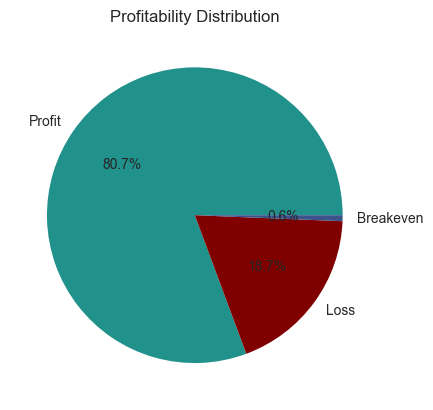

In [97]:
# Visualization of Profitability Distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution')
plt.show()

In [98]:
# ── KEY PERFORMANCE INDICATORS (KPIs) ────────────────────────────────────

# ✅ BUG FIX 4: format_func must handle negative values correctly
# Original code passed negative values directly → '-2055610 $' instead of '-2.1M $'
def format_func(value):
    if pd.isna(value):
        return 'N/A'
    sign  = '-' if value < 0 else ''
    value = abs(value)
    if value >= 1e6:
        return f'{sign}{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{sign}{value/1e3:.1f}K $'
    else:
        return f'{sign}{value:.0f} $'

delayed_df = df[df['Delay'] > 0]
metrics    = {}

metrics['Total Orders']             = len(df)
metrics['Late Deliveries']          = len(delayed_df)
metrics['90% Delay (Days)']         = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %']       = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %']          = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Average Order Profit']     = format_func(df['Order Profit Per Order'].mean())
metrics['Total Profit']             = format_func(df['Order Profit Per Order'].sum())
metrics['Total Loss Due to Delays'] = format_func(
    df.loc[(df['Delay'] > 0) & (df['Order Profit Per Order'] < 0), 'Order Profit Per Order'].sum()
)

# Print the metrics
print("\n📊 Key Performance Indicators (KPIs):")
for key, value in metrics.items():
    if isinstance(value, str):
        print(f"{key}: {value}")
    elif isinstance(value, float) and '%' in key:
        print(f"{key}: {value:.2f}%")
    else:
        print(f"{key}: {value}")


📊 Key Performance Indicators (KPIs):
Total Orders: 172765
Late Deliveries: 94523
90% Delay (Days): 3.00%
On time Delivery %: 45.29%
Late Delivery %: 54.71%
Average Order Profit: 22 $
Total Profit: 3.8M $
Total Loss Due to Delays: -2.1M $


In [99]:
# Summary of the cleaned dataset and KPIs
print("\n✅ Data cleaning and KPI processing complete")
print(f"Final dataset shape: {df.shape}")
print("\nColumns left:")
print(df.columns.tolist())
print("\nFirst 5 rows after cleaning:")
print(df.head())


✅ Data cleaning and KPI processing complete
Final dataset shape: (172765, 28)

Columns left:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Name', 'Customer Country', 'Customer Segment', 'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status', 'Product Name', 'Product Price', 'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour', 'Profitability Flag', 'Profit_Loss_Breakeven']

First 5 rows after cleaning:
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3    

In [100]:
#Profitability and Delivery Time Analysis
profit_metrices = (
    df.groupby('Delay')['Order Profit Per Order']
      .agg(['mean', 'sum', 'count'])
      .reset_index()
)

profit_metrices.columns = ['Delay_Days', 'mean_profit', 'total_profit', 'order_count']


In [101]:
#print profit metrices
print("\nProfitability and Delivery Time Analysis:")
print(profit_metrices)


Profitability and Delivery Time Analysis:
   Delay_Days  mean_profit  total_profit  order_count
0          -2    23.360134  4.875961e+05        20873
1          -1    21.604769  4.476292e+05        20719
2           0    22.249118  8.154302e+05        36650
3           1    22.333227  1.194895e+06        53503
4           2    21.128491  5.821110e+05        27551
5           3    20.031412  1.356527e+05         6772
6           4    21.368783  1.431067e+05         6697


In [102]:
#Delay Distribution Analysis
delay_distribution = (
    df['Delay'].value_counts(normalize=True).sort_index() * 100).reset_index()

print("\nDelay Distribution Analysis:")
print(delay_distribution)


Delay Distribution Analysis:
   Delay  proportion
0     -2   12.081730
1     -1   11.992591
2      0   21.213788
3      1   30.968657
4      2   15.947096
5      3    3.919775
6      4    3.876364



Profit Metrices by Delay Day:


,Delay_Days,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution Analysis:


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


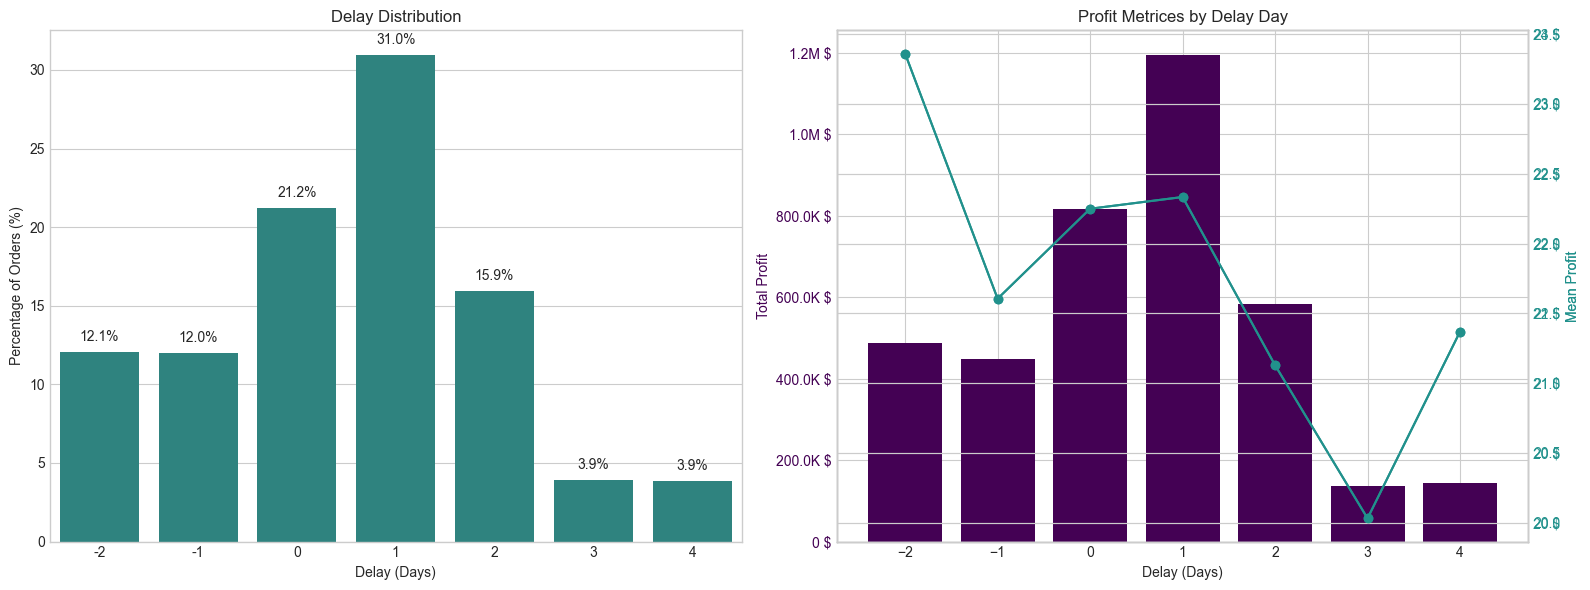

In [103]:
# Clear Visualization

delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrices by Delay Day:")
display(profit_metrices.round(1))

print("\nDelay Distribution Analysis:")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First Subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color=accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# Second Subplot: Profit Metrices by Delay Day
ax2.set_title('Profit Metrices by Delay Day')
ax2.set_xlabel('Delay (Days)')
ax2.set_ylabel('Total Profit', color=primary_color)
ax2.bar(profit_metrices['Delay_Days'], profit_metrices['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

# Create a secondary y-axis for average profit
ax3 = ax2.twinx()
ax3.set_ylabel('Mean Profit', color=accent_color)
ax3.plot(profit_metrices['Delay_Days'], profit_metrices['mean_profit'], color=accent_color, marker='o', label='Mean Profit')
ax3.tick_params(axis='y', labelcolor=accent_color)

#add one more thing Format Total profit to K $,M $
# Format y-axis Total Profit as K$ / M$
def format_profit(value, tick_number):
    sign = '-' if value < 0 else ''
    abs_val = abs(value)
    if abs_val >= 1e6:
        return f'{sign}{abs_val/1e6:.1f}M $'
    elif abs_val >= 1e3:
        return f'{sign}{abs_val/1e3:.1f}K $'
    else:
        return f'{sign}{abs_val:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_profit))

# Create a secondary y-axis for mean profit
ax3 = ax2.twinx()
ax3.set_ylabel('Mean Profit', color=accent_color)
ax3.plot(profit_metrices['Delay_Days'], profit_metrices['mean_profit'], color=accent_color, marker='o', label='Mean Profit')
ax3.tick_params(axis='y', labelcolor=accent_color)
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(format_profit))

plt.tight_layout()
plt.show()
        

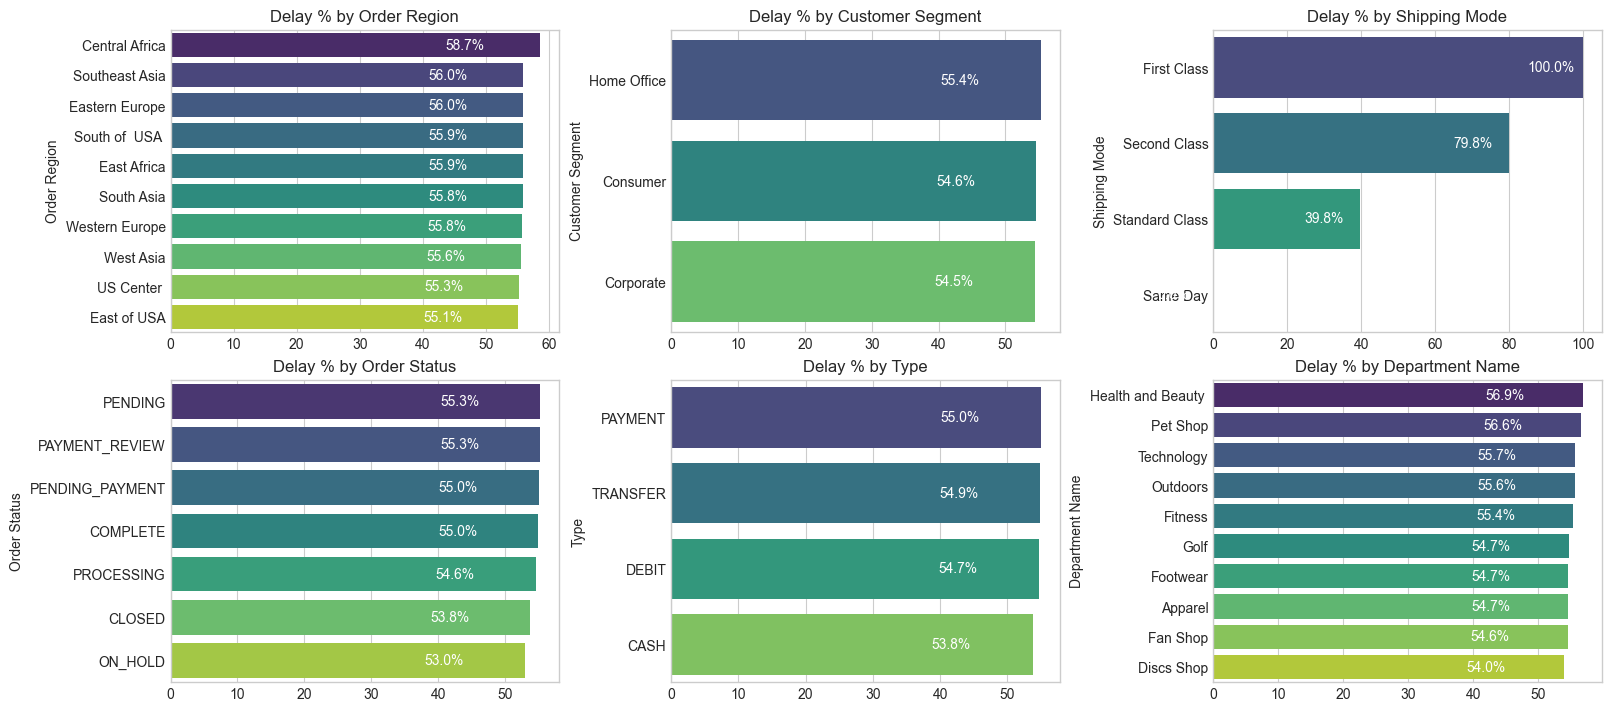

In [104]:
#def compute_pct_by_category(df, category_col, value_col)

def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color='white')

plt.show()

📍 Top 3 Most Delayed Regions:
  Order Region  delay_pct
Central Africa  58.663366
Southeast Asia  55.965412
Eastern Europe  55.957728


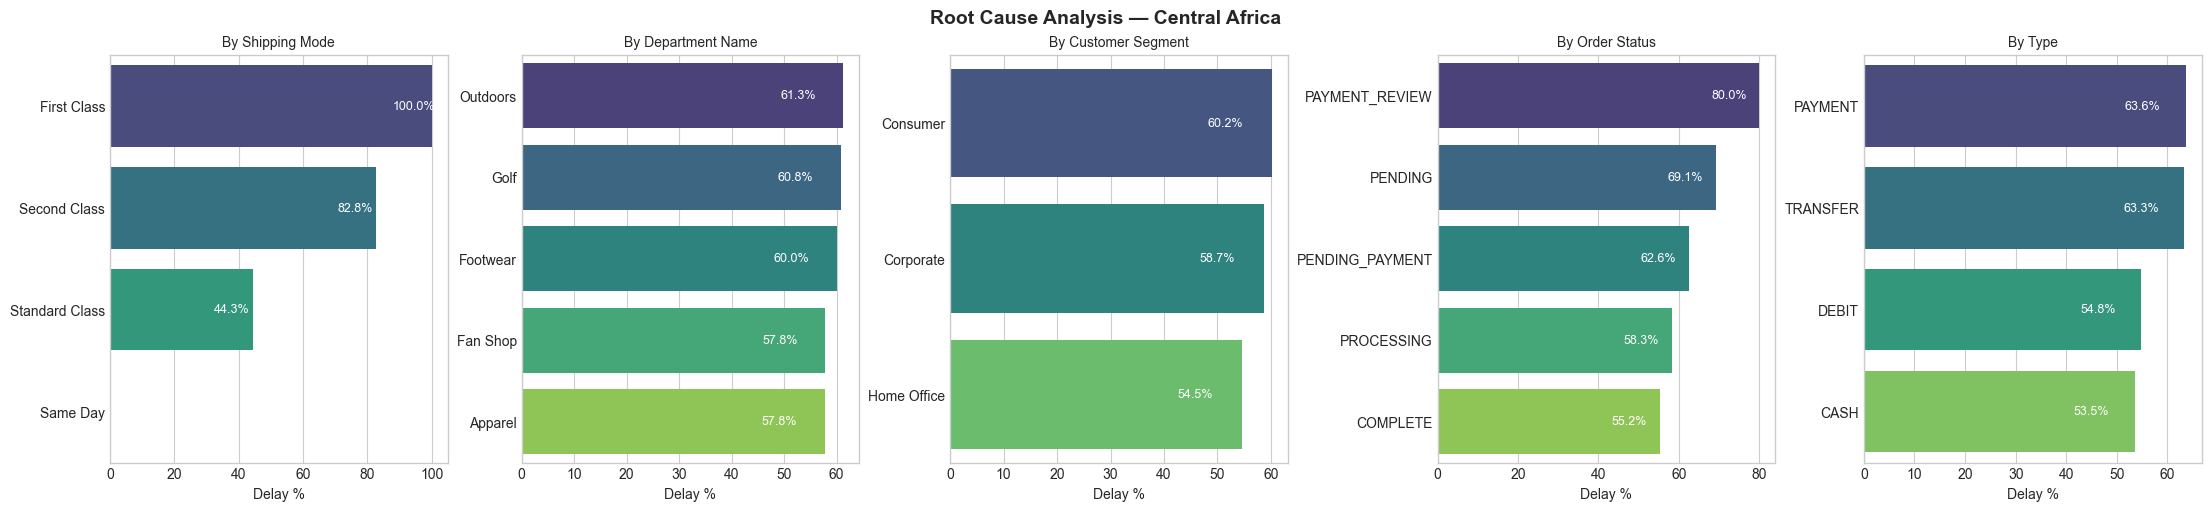

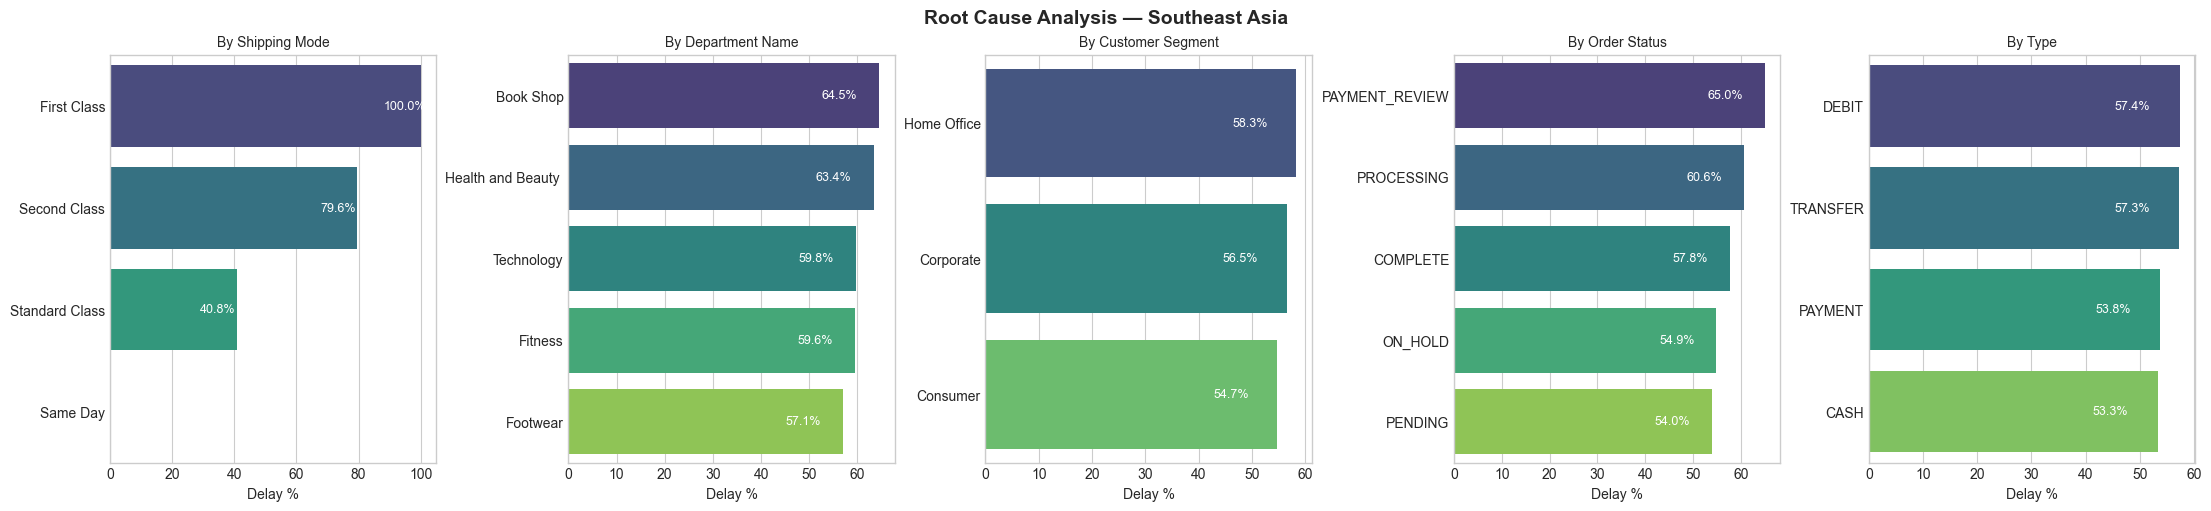

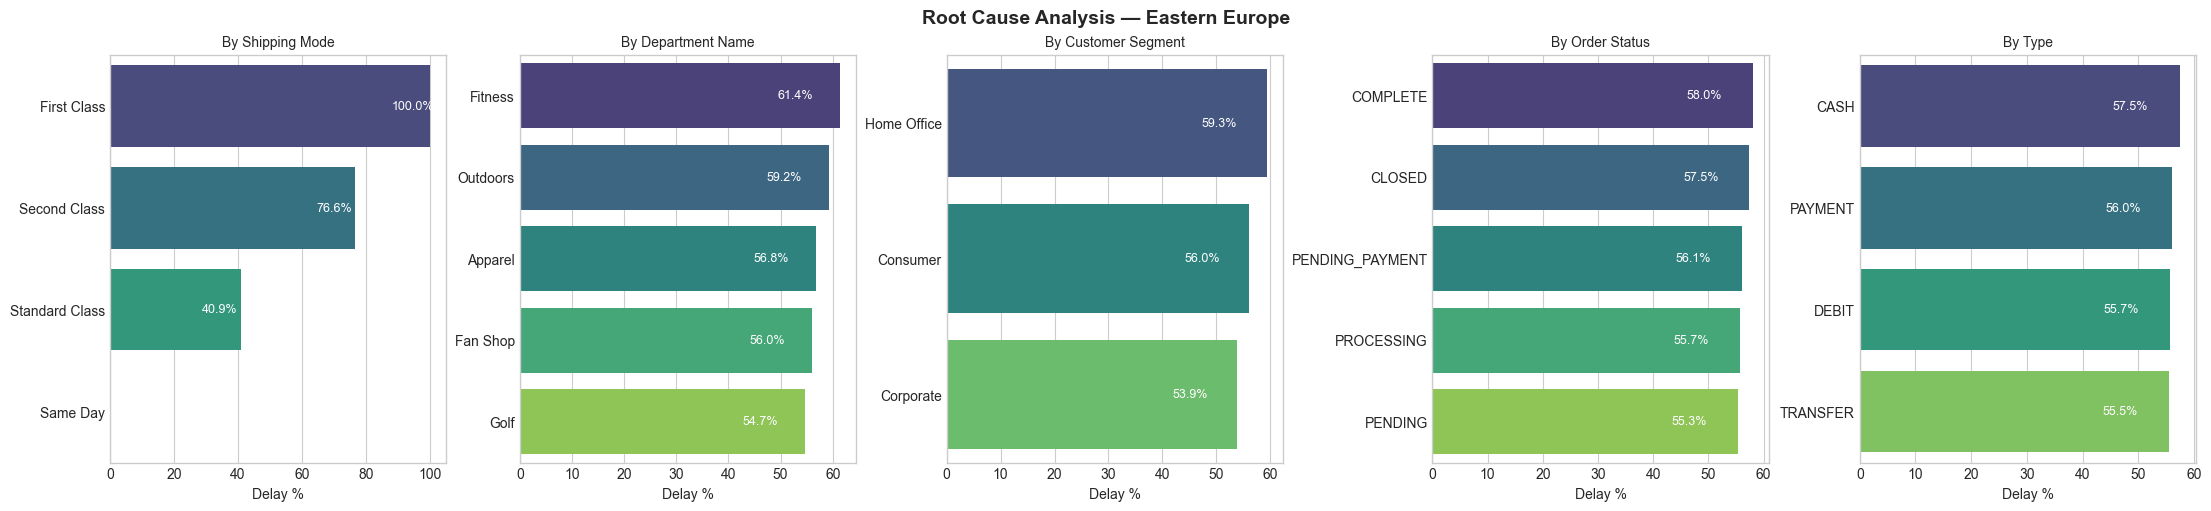

In [105]:
# ── ROOT CAUSE ANALYSIS ───────────────────────────────────────────────────

def top_drivers_for_region(region, top_n=5):
    """
    For a given Order Region, identify the top drivers of delay.
    Breaks down delay % by: Shipping Mode, Department Name, Customer Segment,
    Order Status, and Type — to pinpoint what's causing delays in that region.
    """
    region_df = df[df['Order Region'] == region]

    drivers = {}

    breakdown_cols = ['Shipping Mode', 'Department Name', 'Customer Segment', 'Order Status', 'Type']

    for col in breakdown_cols:
        breakdown = region_df.groupby(col).agg(
            total_orders=('Delay', 'count'),
            late_orders=('Is_Delayed', 'sum')
        ).reset_index()
        breakdown['delay_pct'] = breakdown['late_orders'] / breakdown['total_orders'] * 100
        breakdown = breakdown.sort_values('delay_pct', ascending=False).head(top_n)
        drivers[col] = breakdown

    return drivers


# ── VISUALIZE ROOT CAUSES FOR TOP DELAYED REGIONS ────────────────────────

# Get top 3 most delayed regions
top_regions = (
    df.groupby('Order Region').agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
)
top_regions['delay_pct'] = top_regions['late_orders'] / top_regions['total_orders'] * 100
top_regions = top_regions.sort_values('delay_pct', ascending=False).head(3)

print("📍 Top 3 Most Delayed Regions:")
print(top_regions[['Order Region', 'delay_pct']].to_string(index=False))

# ── PLOT ROOT CAUSES FOR EACH TOP REGION ─────────────────────────────────

for region in top_regions['Order Region']:
    drivers = top_drivers_for_region(region)

    fig, axes = plt.subplots(1, 5, figsize=(22, 5), constrained_layout=True)
    fig.suptitle(f'Root Cause Analysis — {region}', fontsize=14, fontweight='bold')

    for ax, (col, driver_df) in zip(axes, drivers.items()):
        sns.barplot(
            data=driver_df,
            x='delay_pct',
            y=col,
            ax=ax,
            palette='viridis'
        )
        ax.set_title(f'By {col}', fontsize=10)
        ax.set_xlabel('Delay %')
        ax.set_ylabel('')

        for i, row in driver_df.reset_index().iterrows():
            x_pos = max(row['delay_pct'] - 12, 1)
            ax.text(x_pos, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=9, color='white')

    plt.show()

📅 Monthly Delay Analysis:


,month_name,total_orders,late_orders,delay_pct,avg_delay
0,Jan,17289,9380,54.25,0.54
1,Feb,13845,7560,54.60,0.56
2,Mar,15293,8382,54.81,0.54
3,Apr,14775,8053,54.50,0.54
4,May,15166,8341,55.00,0.54
5,Jun,14482,7931,54.76,0.54
6,Jul,15170,8151,53.73,0.52
7,Aug,15305,8477,55.39,0.55
8,Sep,14828,8213,55.39,0.54
9,Oct,12448,6734,54.10,0.52



📆 Day of Week Delay Analysis:


,order_dayofweek_name,total_orders,late_orders,delay_pct,avg_delay
0,Mon,24558,13638,55.53,0.55
1,Tue,24585,13272,53.98,0.52
2,Wed,24447,13408,54.85,0.55
3,Thu,24713,13523,54.72,0.54
4,Fri,24875,13554,54.49,0.54
5,Sat,24754,13432,54.26,0.54
6,Sun,24833,13696,55.15,0.55



⏰ Hourly Delay Analysis:


,order_hour,total_orders,late_orders,delay_pct,avg_delay
0,0,7226,3907,54.07,0.55
1,1,7275,4032,55.42,0.52
2,2,7278,4017,55.19,0.58
3,3,7098,3843,54.14,0.52
4,4,7402,3973,53.67,0.53
5,5,7243,4003,55.27,0.54
6,6,7010,3704,52.84,0.50
7,7,7227,3974,54.99,0.54
8,8,7118,3782,53.13,0.50
9,9,7206,3917,54.36,0.52


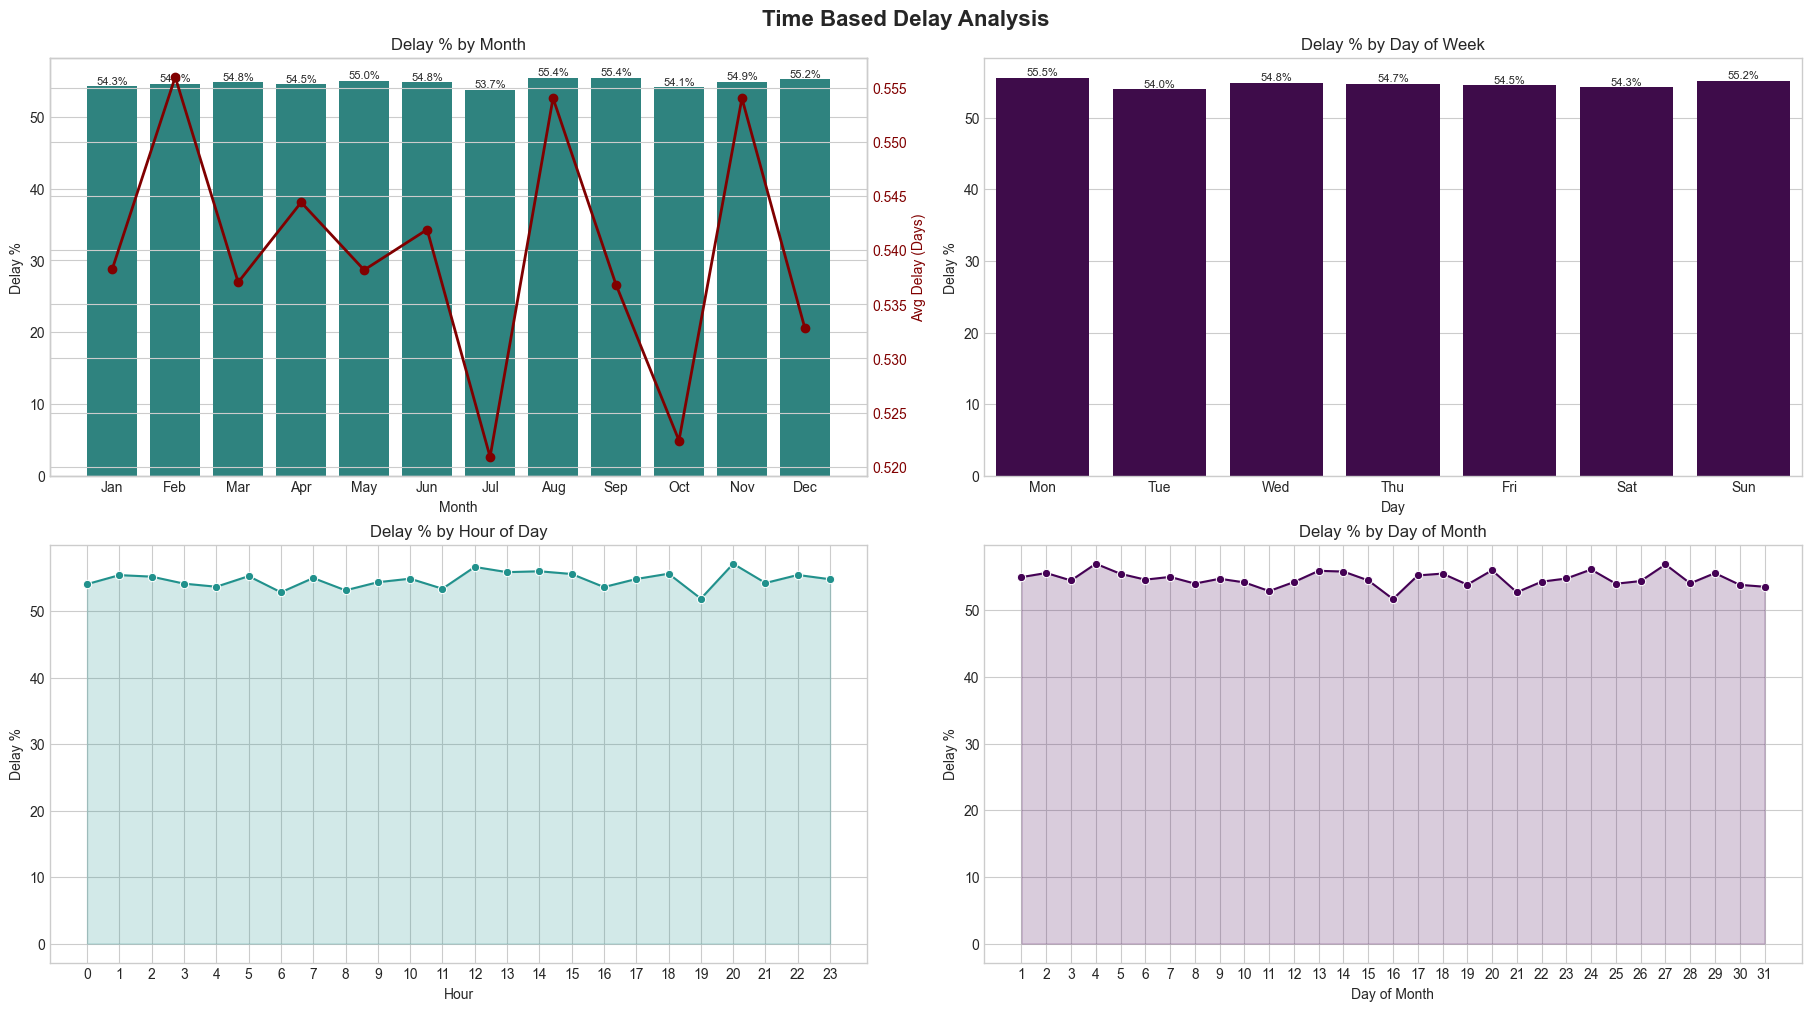

In [106]:
# ── TIME BASED ANALYSIS ───────────────────────────────────────────────────

# ── 1. DELAY % BY MONTH ───────────────────────────────────────────────────
monthly_analysis = df.groupby('order_month').agg(
    total_orders=('Delay', 'count'),
    late_orders=('Is_Delayed', 'sum'),
    avg_delay=('Delay', 'mean')
).reset_index()
monthly_analysis['delay_pct'] = monthly_analysis['late_orders'] / monthly_analysis['total_orders'] * 100
monthly_analysis['month_name'] = pd.to_datetime(monthly_analysis['order_month'], format='%m').dt.strftime('%b')

# ── 2. DELAY % BY DAY OF MONTH ────────────────────────────────────────────
daily_analysis = df.groupby('order_day').agg(
    total_orders=('Delay', 'count'),
    late_orders=('Is_Delayed', 'sum'),
    avg_delay=('Delay', 'mean')
).reset_index()
daily_analysis['delay_pct'] = daily_analysis['late_orders'] / daily_analysis['total_orders'] * 100

# ── 3. DELAY % BY HOUR ────────────────────────────────────────────────────
hourly_analysis = df.groupby('order_hour').agg(
    total_orders=('Delay', 'count'),
    late_orders=('Is_Delayed', 'sum'),
    avg_delay=('Delay', 'mean')
).reset_index()
hourly_analysis['delay_pct'] = hourly_analysis['late_orders'] / hourly_analysis['total_orders'] * 100

# ── 4. DELAY % BY DAY OF WEEK ─────────────────────────────────────────────
df['order_dayofweek'] = df['order date (DateOrders)'].dt.dayofweek
df['order_dayofweek_name'] = df['order date (DateOrders)'].dt.strftime('%a')

dow_analysis = df.groupby(['order_dayofweek', 'order_dayofweek_name']).agg(
    total_orders=('Delay', 'count'),
    late_orders=('Is_Delayed', 'sum'),
    avg_delay=('Delay', 'mean')
).reset_index().sort_values('order_dayofweek')
dow_analysis['delay_pct'] = dow_analysis['late_orders'] / dow_analysis['total_orders'] * 100

# ── PRINT SUMMARIES ───────────────────────────────────────────────────────
print("📅 Monthly Delay Analysis:")
display(monthly_analysis[['month_name', 'total_orders', 'late_orders', 'delay_pct', 'avg_delay']].round(2))

print("\n📆 Day of Week Delay Analysis:")
display(dow_analysis[['order_dayofweek_name', 'total_orders', 'late_orders', 'delay_pct', 'avg_delay']].round(2))

print("\n⏰ Hourly Delay Analysis:")
display(hourly_analysis[['order_hour', 'total_orders', 'late_orders', 'delay_pct', 'avg_delay']].round(2))

# ── VISUALIZATION ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10), constrained_layout=True)
fig.suptitle('Time Based Delay Analysis', fontsize=16, fontweight='bold')

# ── SUBPLOT 1: Delay % by Month ───────────────────────────────────────────
ax1 = axes[0, 0]
sns.barplot(data=monthly_analysis, x='month_name', y='delay_pct', color=accent_color, ax=ax1)
ax2_twin = ax1.twinx()
ax2_twin.plot(range(len(monthly_analysis)), monthly_analysis['avg_delay'], color=danger_color, marker='o', linewidth=2, label='Avg Delay (days)')
ax2_twin.set_ylabel('Avg Delay (Days)', color=danger_color)
ax2_twin.tick_params(axis='y', labelcolor=danger_color)
ax1.set_title('Delay % by Month')
ax1.set_xlabel('Month')
ax1.set_ylabel('Delay %')
for i, row in monthly_analysis.iterrows():
    ax1.text(i, row['delay_pct'] + 0.3, f"{row['delay_pct']:.1f}%", ha='center', fontsize=8)

# ── SUBPLOT 2: Delay % by Day of Week ────────────────────────────────────
ax2 = axes[0, 1]
sns.barplot(data=dow_analysis, x='order_dayofweek_name', y='delay_pct', color=primary_color, ax=ax2)
ax2.set_title('Delay % by Day of Week')
ax2.set_xlabel('Day')
ax2.set_ylabel('Delay %')
for i, row in dow_analysis.reset_index().iterrows():
    ax2.text(i, row['delay_pct'] + 0.3, f"{row['delay_pct']:.1f}%", ha='center', fontsize=8)

# ── SUBPLOT 3: Delay % by Hour ────────────────────────────────────────────
ax3 = axes[1, 0]
sns.lineplot(data=hourly_analysis, x='order_hour', y='delay_pct', color=accent_color, marker='o', ax=ax3)
ax3.fill_between(hourly_analysis['order_hour'], hourly_analysis['delay_pct'], alpha=0.2, color=accent_color)
ax3.set_title('Delay % by Hour of Day')
ax3.set_xlabel('Hour')
ax3.set_ylabel('Delay %')
ax3.set_xticks(range(0, 24))

# ── SUBPLOT 4: Delay % by Day of Month ───────────────────────────────────
ax4 = axes[1, 1]
sns.lineplot(data=daily_analysis, x='order_day', y='delay_pct', color=primary_color, marker='o', ax=ax4)
ax4.fill_between(daily_analysis['order_day'], daily_analysis['delay_pct'], alpha=0.2, color=primary_color)
ax4.set_title('Delay % by Day of Month')
ax4.set_xlabel('Day of Month')
ax4.set_ylabel('Delay %')
ax4.set_xticks(range(1, 32))

plt.show()

✅ Categorical columns encoded
📊 Dataset shape for ML: (172765, 14)
🎯 Target distribution:
Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

✅ Train size: 138212 | Test size: 34553

🔄 Training Logistic Regression...
✅ Logistic Regression — AUC: 0.6966
              precision    recall  f1-score   support

     On Time       0.53      0.86      0.66     15648
     Delayed       0.76      0.38      0.50     18905

    accuracy                           0.59     34553
   macro avg       0.65      0.62      0.58     34553
weighted avg       0.66      0.59      0.57     34553


🔄 Training Random Forest...
✅ Random Forest — AUC: 0.9107
              precision    recall  f1-score   support

     On Time       0.76      0.88      0.81     15648
     Delayed       0.88      0.77      0.82     18905

    accuracy                           0.82     34553
   macro avg       0.82      0.82      0.82     34553
weighted avg       0.83      0.82      0.82     34553


🔄 Training Gradie

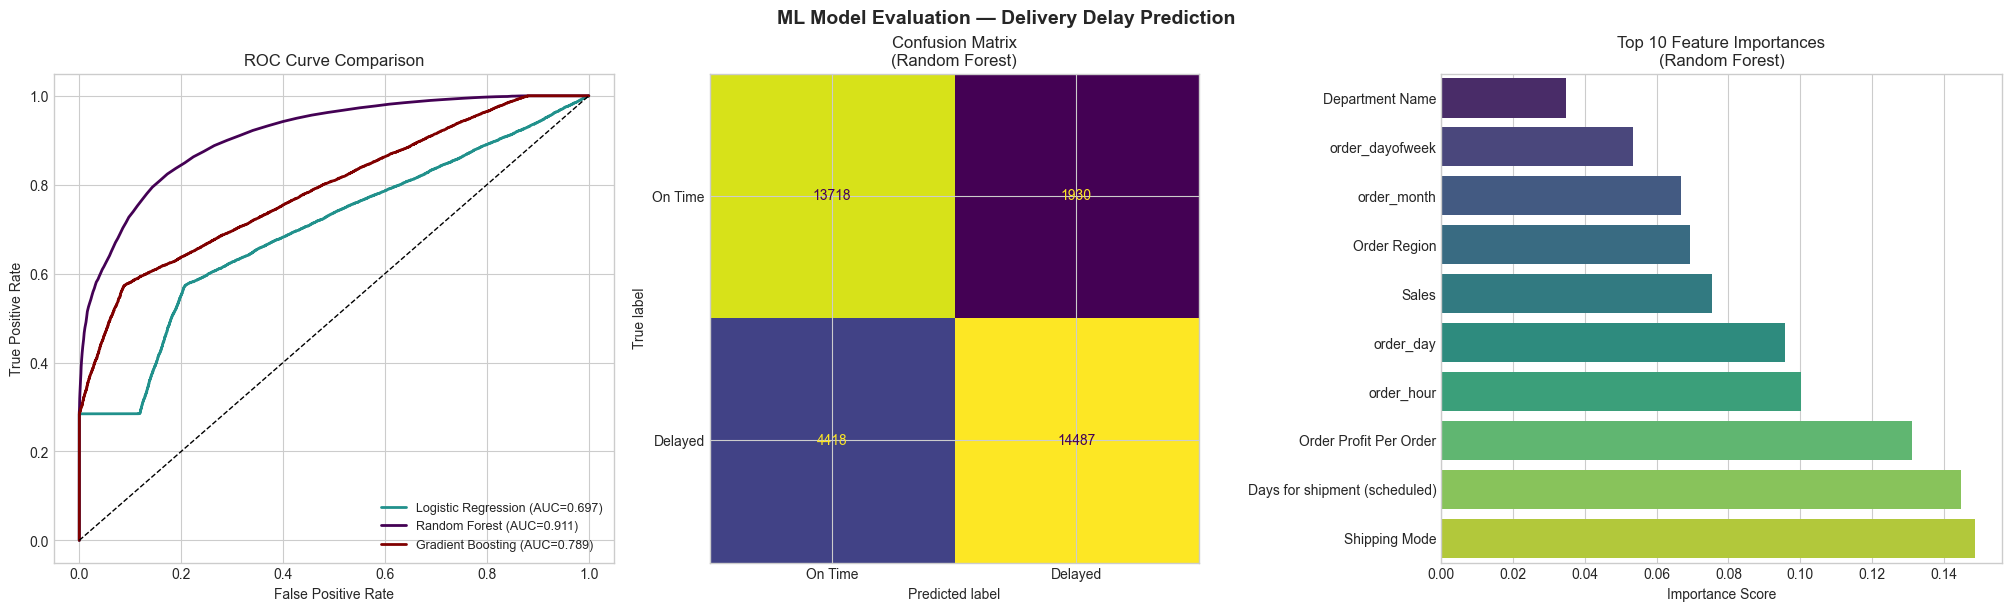


📊 Model Comparison Summary:
Model                          AUC
-----------------------------------
Random Forest               0.9107 🏆
Gradient Boosting           0.7892
Logistic Regression         0.6966

🔮 Example Prediction on a New Order:
Prediction : 🔴 DELAYED
Delay Probability: 100.00%
✅ Categorical columns encoded
📊 Dataset shape for ML: (172765, 14)
🎯 Target distribution:
Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

✅ Train size: 138212 | Test size: 34553

🔄 Training Logistic Regression...
✅ Logistic Regression — AUC: 0.6966
              precision    recall  f1-score   support

     On Time       0.53      0.86      0.66     15648
     Delayed       0.76      0.38      0.50     18905

    accuracy                           0.59     34553
   macro avg       0.65      0.62      0.58     34553
weighted avg       0.66      0.59      0.57     34553


🔄 Training Random Forest...
✅ Random Forest — AUC: 0.9107
              precision    recall  f1-score   supp

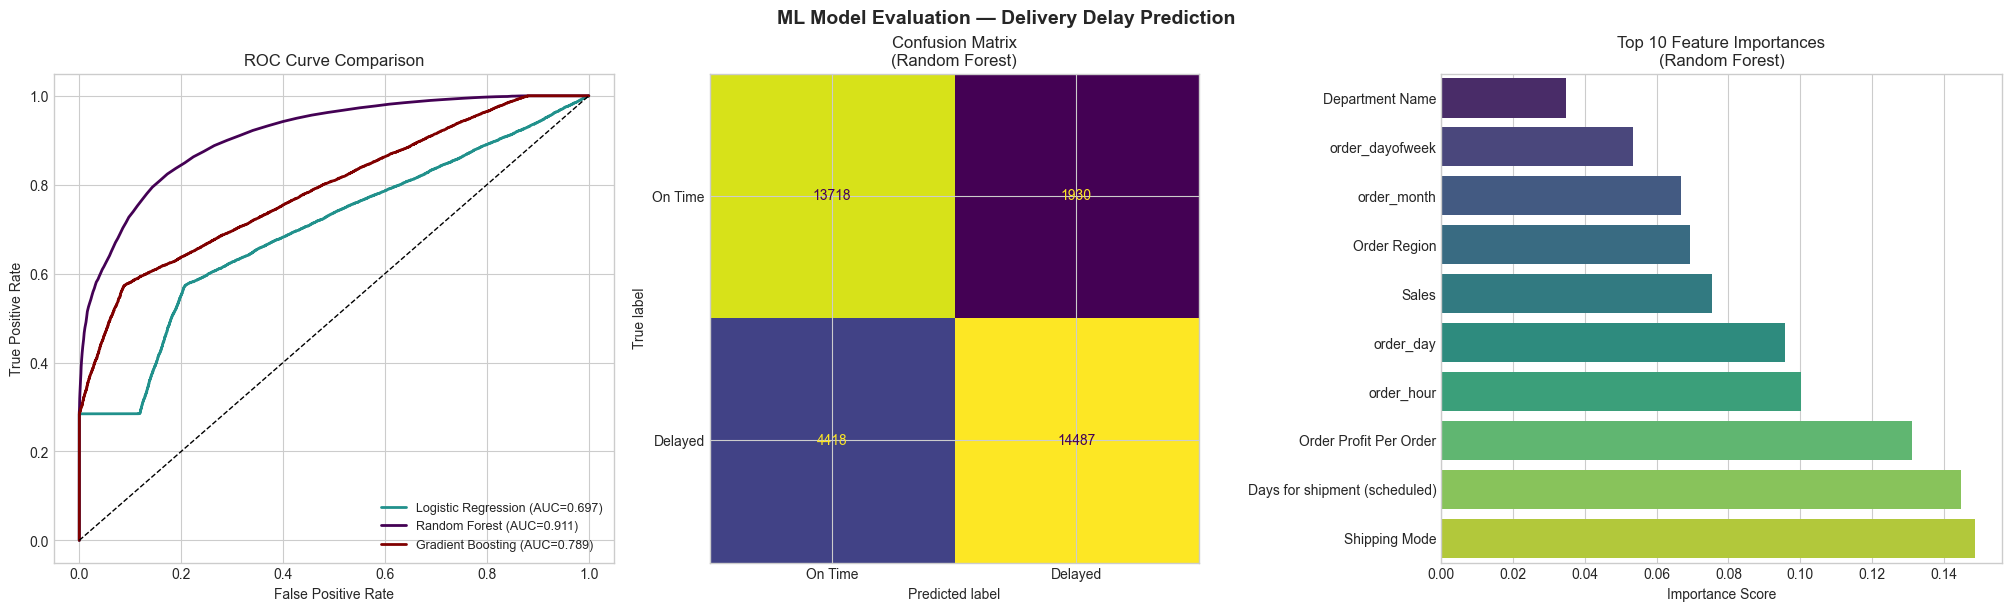


📊 Model Comparison Summary:
Model                          AUC
-----------------------------------
Random Forest               0.9107 🏆
Gradient Boosting           0.7892
Logistic Regression         0.6966

🔮 Example Prediction on a New Order:
Prediction : 🔴 DELAYED
Delay Probability: 100.00%


In [107]:
#Predict model on # ── ML MODEL: DELIVERY DELAY PREDICTION ──────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── 1. FEATURE SELECTION ──────────────────────────────────────────────────
features = [
    'Shipping Mode',
    'Order Region',
    'Customer Segment',
    'Type',
    'Department Name',
    'Order Status',
    'Days for shipment (scheduled)',
    'Order Profit Per Order',
    'Sales',
    'order_month',
    'order_day',
    'order_hour',
    'order_dayofweek'
]
target = 'Is_Delayed'

ml_df = df[features + [target]].copy()

# ── 2. ENCODE CATEGORICAL COLUMNS ────────────────────────────────────────
categorical_cols = ['Shipping Mode', 'Order Region', 'Customer Segment',
                    'Type', 'Department Name', 'Order Status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    label_encoders[col] = le

print("✅ Categorical columns encoded")
print(f"📊 Dataset shape for ML: {ml_df.shape}")
print(f"🎯 Target distribution:\n{ml_df[target].value_counts()}")

# ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────────────
X = ml_df[features]
y = ml_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ── 4. TRAIN 3 MODELS ─────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_pred_prob)
    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'y_pred_prob':y_pred_prob,
        'auc':        auc,
        'report':     classification_report(y_test, y_pred, target_names=['On Time', 'Delayed'])
    }
    print(f"✅ {name} — AUC: {auc:.4f}")
    print(results[name]['report'])

# ── 5. PICK BEST MODEL ────────────────────────────────────────────────────
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model      = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name} (AUC: {results[best_model_name]['auc']:.4f})")

# ── 6. VISUALIZATION ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle('ML Model Evaluation — Delivery Delay Prediction', fontsize=14, fontweight='bold')

# ── SUBPLOT 1: ROC Curves (all 3 models) ─────────────────────────────────
ax1 = axes[0]
colors_roc = [accent_color, primary_color, danger_color]
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_title('ROC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=9)

# ── SUBPLOT 2: Confusion Matrix (best model) ─────────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot(ax=ax2, colorbar=False, cmap='viridis')
ax2.set_title(f'Confusion Matrix\n({best_model_name})')

# ── SUBPLOT 3: Feature Importance (best model) ───────────────────────────
ax3 = axes[2]
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature':    features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(10)
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Top 10 Feature Importances\n({best_model_name})')
    ax3.set_xlabel('Importance Score')
    ax3.set_ylabel('')
else:
    # Logistic Regression — use coefficients
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': abs(best_model.coef_[0])
    }).sort_values('Coefficient', ascending=True).tail(10)
    sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Top 10 Feature Coefficients\n({best_model_name})')
    ax3.set_xlabel('|Coefficient|')
    ax3.set_ylabel('')

plt.show()

# ── 7. MODEL COMPARISON SUMMARY ───────────────────────────────────────────
print("\n📊 Model Comparison Summary:")
print(f"{'Model':<25} {'AUC':>8}")
print("-" * 35)
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    marker = " 🏆" if name == best_model_name else ""
    print(f"{name:<25} {res['auc']:>8.4f}{marker}")

# ── 8. PREDICT ON NEW ORDER (example) ────────────────────────────────────
print("\n🔮 Example Prediction on a New Order:")

sample_order = X_test.iloc[[0]].copy()
pred         = best_model.predict(sample_order)[0]
prob         = best_model.predict_proba(sample_order)[0][1]

print(f"Prediction : {'🔴 DELAYED' if pred == 1 else '🟢 ON TIME'}")
print(f"Delay Probability: {prob:.2%}")# ── ML MODEL: DELIVERY DELAY PREDICTION ──────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# ── 1. FEATURE SELECTION ──────────────────────────────────────────────────
features = [
    'Shipping Mode',
    'Order Region',
    'Customer Segment',
    'Type',
    'Department Name',
    'Order Status',
    'Days for shipment (scheduled)',
    'Order Profit Per Order',
    'Sales',
    'order_month',
    'order_day',
    'order_hour',
    'order_dayofweek'
]
target = 'Is_Delayed'

ml_df = df[features + [target]].copy()

# ── 2. ENCODE CATEGORICAL COLUMNS ────────────────────────────────────────
categorical_cols = ['Shipping Mode', 'Order Region', 'Customer Segment',
                    'Type', 'Department Name', 'Order Status']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    label_encoders[col] = le

print("✅ Categorical columns encoded")
print(f"📊 Dataset shape for ML: {ml_df.shape}")
print(f"🎯 Target distribution:\n{ml_df[target].value_counts()}")

# ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────────────
X = ml_df[features]
y = ml_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ── 4. TRAIN 3 MODELS ─────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc         = roc_auc_score(y_test, y_pred_prob)
    results[name] = {
        'model':      model,
        'y_pred':     y_pred,
        'y_pred_prob':y_pred_prob,
        'auc':        auc,
        'report':     classification_report(y_test, y_pred, target_names=['On Time', 'Delayed'])
    }
    print(f"✅ {name} — AUC: {auc:.4f}")
    print(results[name]['report'])

# ── 5. PICK BEST MODEL ────────────────────────────────────────────────────
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model      = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name} (AUC: {results[best_model_name]['auc']:.4f})")

# ── 6. VISUALIZATION ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig.suptitle('ML Model Evaluation — Delivery Delay Prediction', fontsize=14, fontweight='bold')

# ── SUBPLOT 1: ROC Curves (all 3 models) ─────────────────────────────────
ax1 = axes[0]
colors_roc = [accent_color, primary_color, danger_color]
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax1.set_title('ROC Curve Comparison')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(fontsize=9)

# ── SUBPLOT 2: Confusion Matrix (best model) ─────────────────────────────
ax2 = axes[1]
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On Time', 'Delayed'])
disp.plot(ax=ax2, colorbar=False, cmap='viridis')
ax2.set_title(f'Confusion Matrix\n({best_model_name})')

# ── SUBPLOT 3: Feature Importance (best model) ───────────────────────────
ax3 = axes[2]
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature':    features,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(10)
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Top 10 Feature Importances\n({best_model_name})')
    ax3.set_xlabel('Importance Score')
    ax3.set_ylabel('')
else:
    # Logistic Regression — use coefficients
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': abs(best_model.coef_[0])
    }).sort_values('Coefficient', ascending=True).tail(10)
    sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Top 10 Feature Coefficients\n({best_model_name})')
    ax3.set_xlabel('|Coefficient|')
    ax3.set_ylabel('')

plt.show()

# ── 7. MODEL COMPARISON SUMMARY ───────────────────────────────────────────
print("\n📊 Model Comparison Summary:")
print(f"{'Model':<25} {'AUC':>8}")
print("-" * 35)
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    marker = " 🏆" if name == best_model_name else ""
    print(f"{name:<25} {res['auc']:>8.4f}{marker}")

# ── 8. PREDICT ON NEW ORDER (example) ────────────────────────────────────
print("\n🔮 Example Prediction on a New Order:")

sample_order = X_test.iloc[[0]].copy()
pred         = best_model.predict(sample_order)[0]
prob         = best_model.predict_proba(sample_order)[0][1]

print(f"Prediction : {'🔴 DELAYED' if pred == 1 else '🟢 ON TIME'}")
print(f"Delay Probability: {prob:.2%}")